In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv("processed_df.csv")
df

,Session_Summary,tokens,words_count,sentence_count
0,we started our lecture with a recap of previou...,"['we', 'started', 'our', 'lecture', 'with', 'a...",224,16
1,"in this session, we explored various feature e...","['in', 'this', 'session', 'we', 'explored', 'v...",271,16
2,population and sample were further discussed u...,"['population', 'and', 'sample', 'were', 'furth...",336,22
3,we first looked at all the summaries and obser...,"['we', 'first', 'looked', 'at', 'all', 'the', ...",219,13
4,midsem metrics for evaluation and also discuss...,"['midsem', 'metrics', 'for', 'evaluation', 'an...",13,1
...,...,...,...,...
662,in this lecture we have learnt about what is p...,"['in', 'this', 'lecture', 'we', 'have', 'learn...",326,15
663,"today, we continued our discussion on statisti...","['today', 'we', 'continued', 'our', 'discussio...",97,5
664,"at the beginning, sir explained what are the w...","['at', 'the', 'beginning', 'sir', 'explained',...",231,16
665,we studied about crisp-dm\n(cross industry sta...,"['we', 'studied', 'about', 'crispdm', 'cross',...",106,6


In [20]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,  # Limit features to reduce dimensionality
    stop_words='english',  # Remove common English stop words
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.9  # Ignore terms that appear in more than 90% of documents
)

# Fit and transform the summaries to TF-IDF vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Session_Summary'])

# Normalize the TF-IDF vectors
tfidf_matrix_normalized = normalize(tfidf_matrix)
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14916 stored elements and shape (667, 100)>
  Coords	Values
  (0, 80)	0.38548517045958375
  (0, 37)	0.2364095087580472
  (0, 93)	0.3074541943474751
  (0, 5)	0.23565084597368097
  (0, 52)	0.2666639364459283
  (0, 40)	0.22470748274014815
  (0, 72)	0.11952430481976059
  (0, 27)	0.436035774947729
  (0, 38)	0.15605275110276373
  (0, 45)	0.3279111176974556
  (0, 90)	0.08045256990148915
  (0, 24)	0.12219782772376934
  (0, 49)	0.13312739324129266
  (0, 4)	0.124788137063901
  (0, 92)	0.3109306317417318
  (0, 67)	0.13710436334323176
  (0, 3)	0.11217769047334904
  (0, 50)	0.06927187489013241
  (1, 93)	0.032822284497703205
  (1, 52)	0.037956958568008695
  (1, 45)	0.09334977105879134
  (1, 90)	0.03435486893886593
  (1, 92)	0.09958023512156569
  (1, 76)	0.050153288198563815
  (1, 97)	0.05165228632415522
  :	:
  (665, 58)	0.2795562004850144
  (665, 79)	0.1294067182868434
  (665, 48)	0.6070296736516859
  (665, 70)	0.36559059495851415
  (666

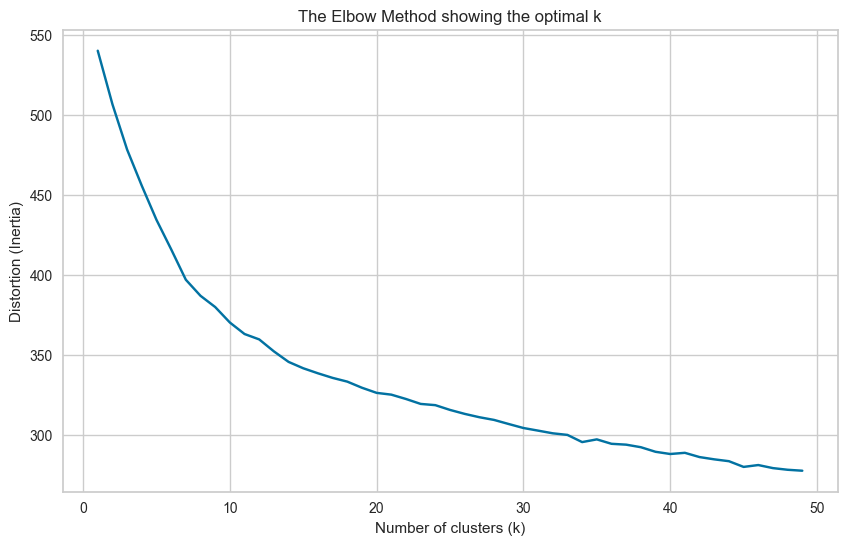

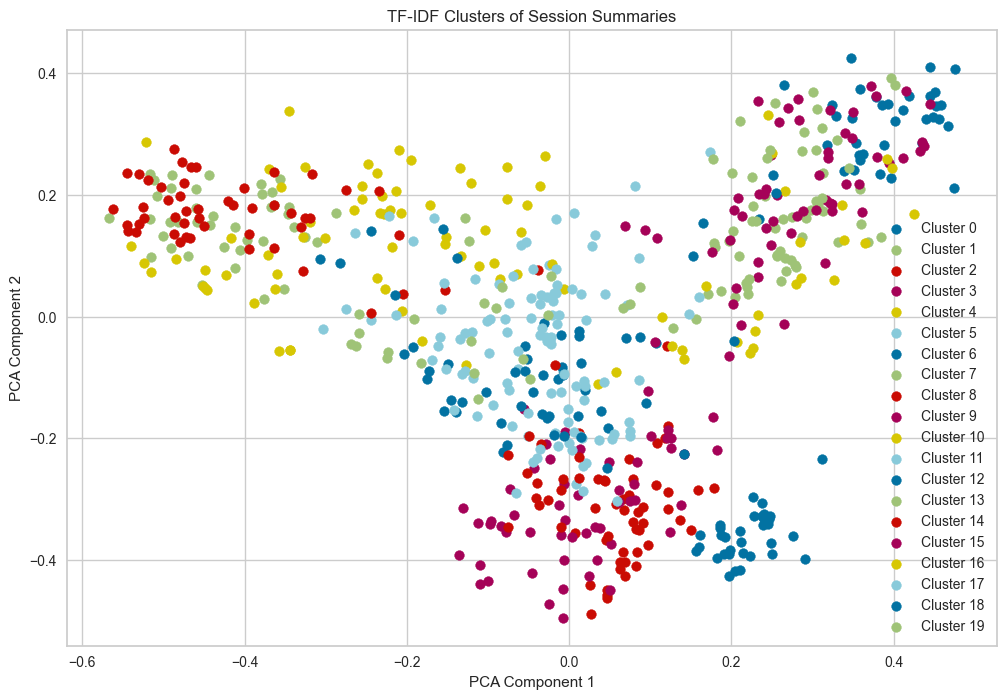

Top terms per cluster:
Cluster 0:
data, missing, outliers, understanding, eda, values, analysis, mean, plots, random

Cluster 1:
population, sample, parameters, line, sum, mean, simple, confidence, fit, statistics

Cluster 2:
clustering, curve, positive, means, classification, true, points, logistic, model, data

Cluster 3:
learning, nominal, ordinal, ratio, interval, data, regression, clustering, classification, example

Cluster 4:
regression, error, excel, distribution, data, model, errors, linear, plot, line

Cluster 5:
function, probability, logistic, class, matrix, metrics, regression, discussed, using, model

Cluster 6:
encoding, feature, data, values, dimensionality, variable, discussed, variables, problem, class

Cluster 7:
pca, vif, data, variance, analysis, features, dimensionality, distribution, number, used

Cluster 8:
distribution, sample, mean, population, standard, confidence, normal, samples, regression, means

Cluster 9:
data, analysis, eda, session, excel, using, data

In [21]:
distortions = []
K = range(1, 50)  # Test different numbers of clusters
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix_normalized)
    distortions.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, distortions, "bx-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion (Inertia)")
plt.title("The Elbow Method showing the optimal k")
plt.grid(True)
plt.show()

# Based on the elbow curve, choose an appropriate number of clusters
# For this example, let's assume k=4 is optimal
optimal_k = 20

# Train the KMeans model with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix_normalized)

# Add the cluster labels to the original dataframe
df["Cluster"] = clusters

# Visualize the clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
tfidf_matrix_2d = pca.fit_transform(tfidf_matrix_normalized.toarray())

# Create a scatter plot of the clusters
plt.figure(figsize=(12, 8))
for cluster_num in range(optimal_k):
    # Get points in this cluster
    cluster_points = tfidf_matrix_2d[clusters == cluster_num]
    plt.scatter(
        cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_num}"
    )

plt.title("TF-IDF Clusters of Session Summaries")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# Print the most common terms in each cluster
print("Top terms per cluster:")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()

for i in range(optimal_k):
    print(f"Cluster {i}:")
    # Print top 10 terms for each cluster
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))
    print()

# Print a few examples from each cluster
print("Sample summaries from each cluster:")
for i in range(optimal_k):
    print(f"Cluster {i} samples:")
    # Get 10 random samples from this cluster
    cluster_samples = (
        df[df["Cluster"] == i]["Session_Summary"]
        .sample(min(10, len(df[df["Cluster"] == i])))
        .values
    )
    for j, sample in enumerate(cluster_samples):
        print(f"Sample {j+1}: {sample}...")  # Print first 200 chars
    print()


Analyzing Cluster 0 (35 documents)
Average similarity within cluster: 0.6408


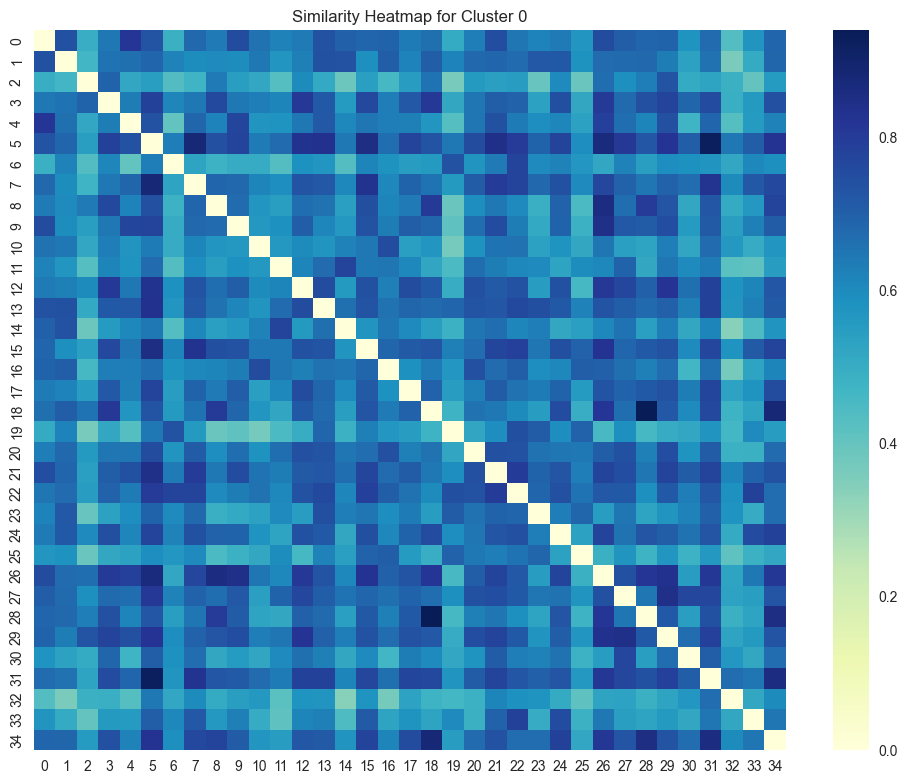


Analyzing Cluster 1 (43 documents)
Average similarity within cluster: 0.5549


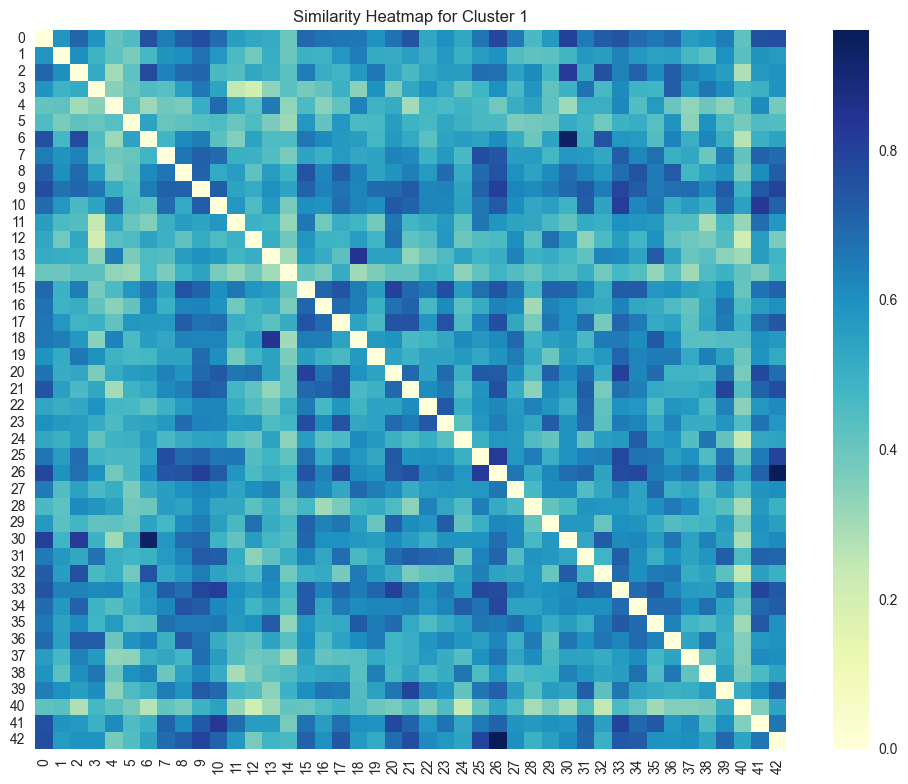


Analyzing Cluster 2 (40 documents)
Average similarity within cluster: 0.5146


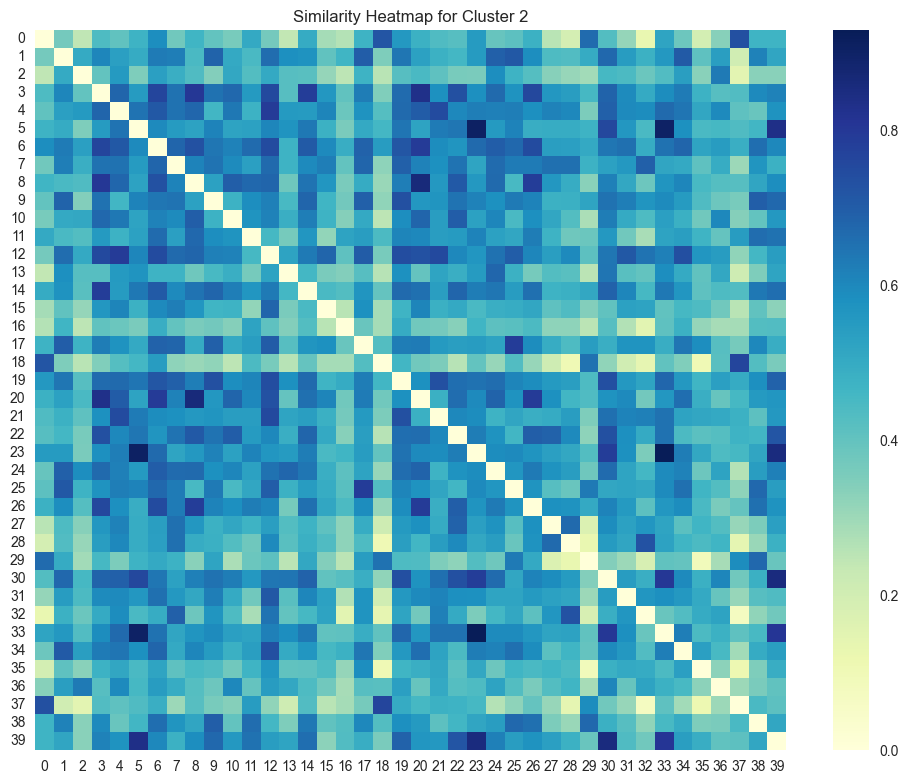


Analyzing Cluster 3 (55 documents)
Average similarity within cluster: 0.5337


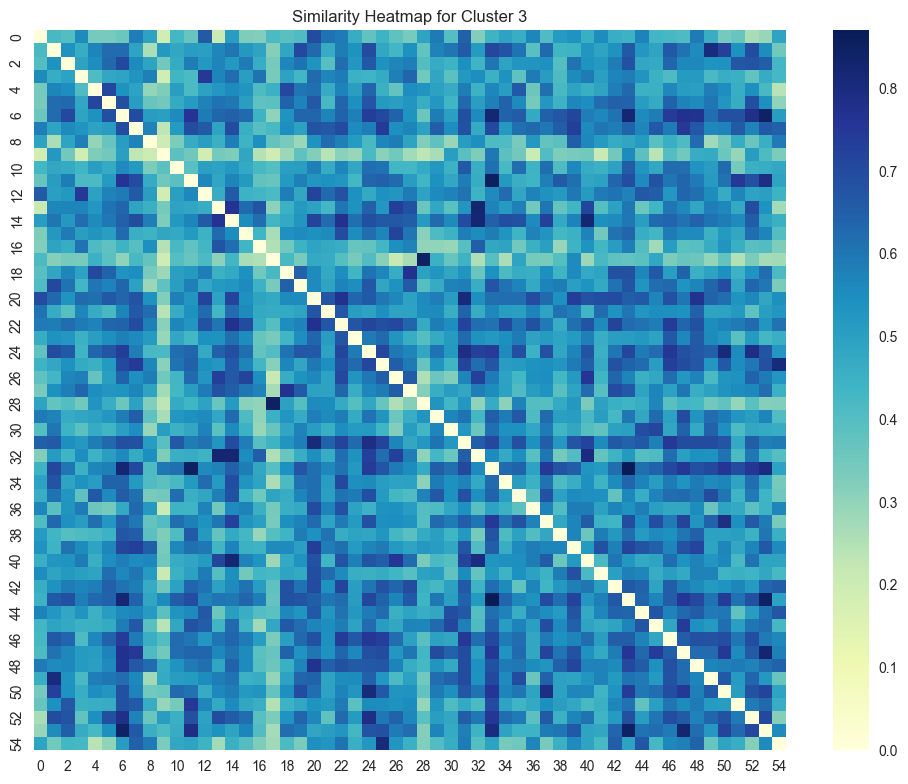


Analyzing Cluster 4 (43 documents)
Average similarity within cluster: 0.4508


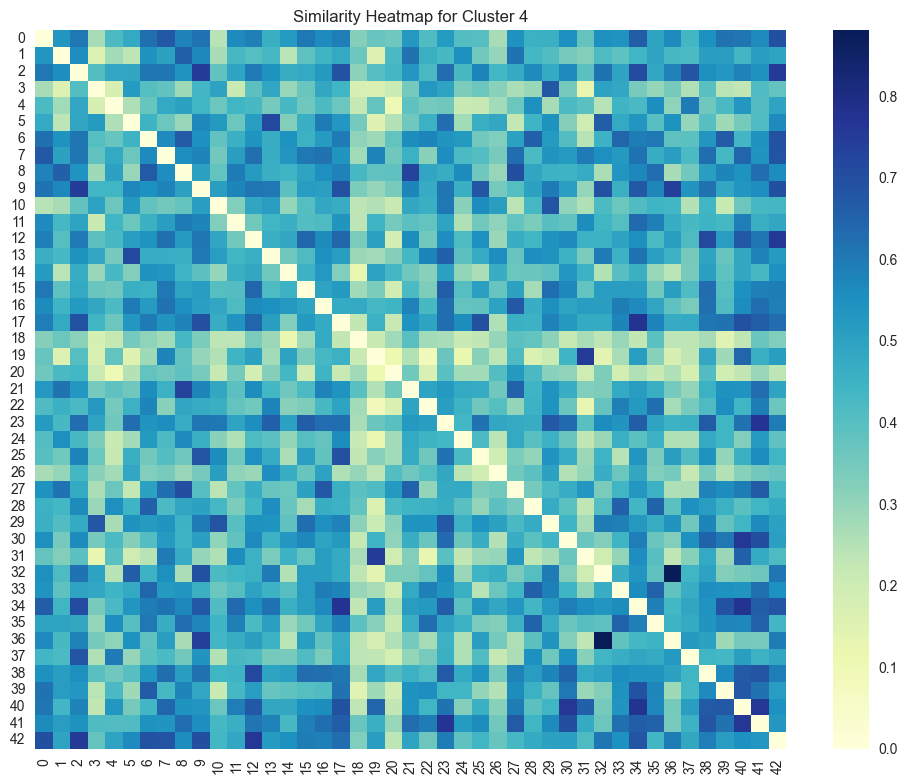


Analyzing Cluster 5 (33 documents)
Average similarity within cluster: 0.3531


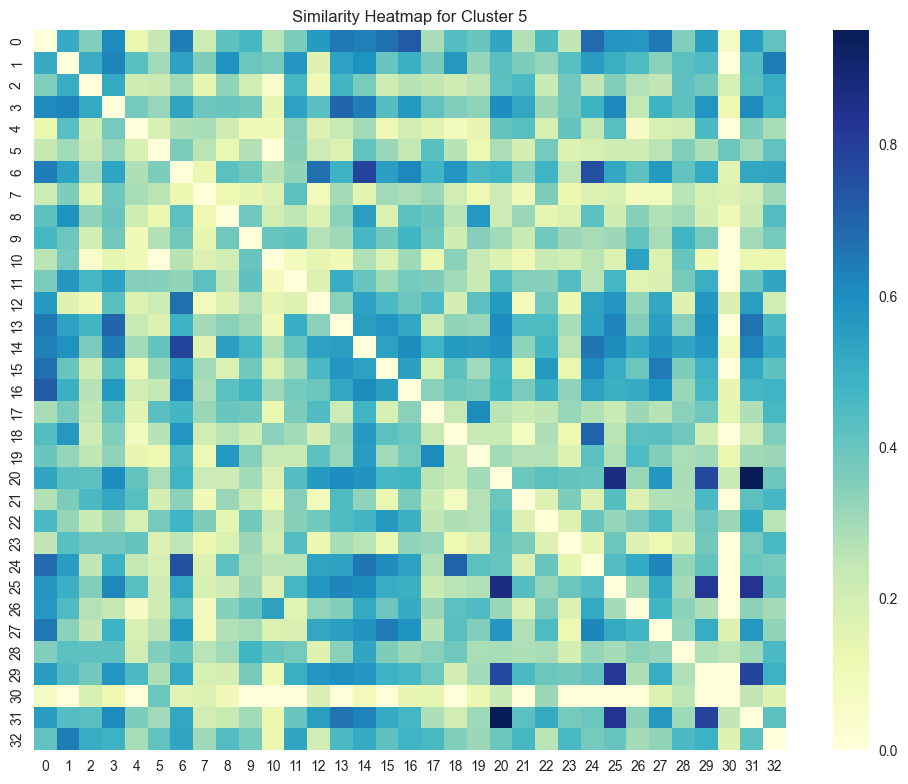


Analyzing Cluster 6 (34 documents)
Average similarity within cluster: 0.7875


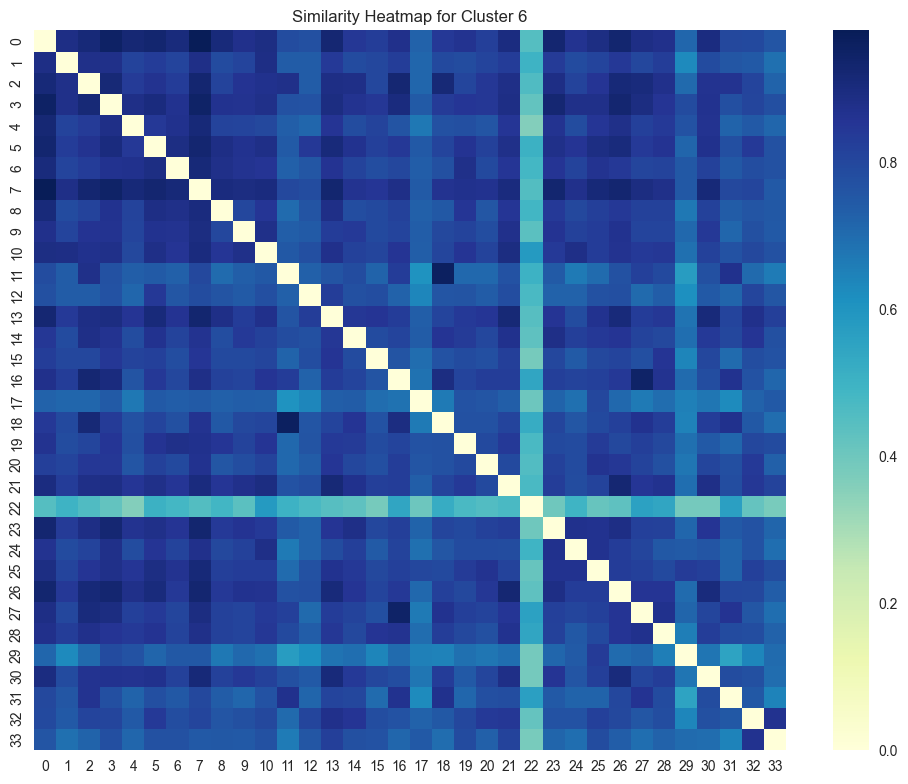


Analyzing Cluster 7 (33 documents)
Average similarity within cluster: 0.6885


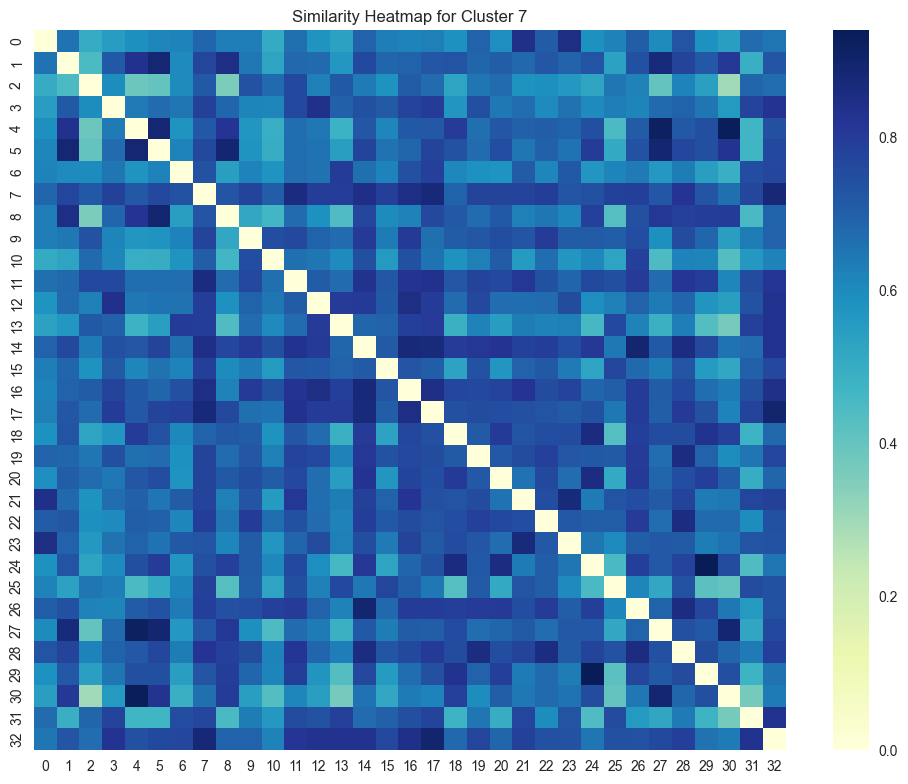


Analyzing Cluster 8 (50 documents)
Average similarity within cluster: 0.5090


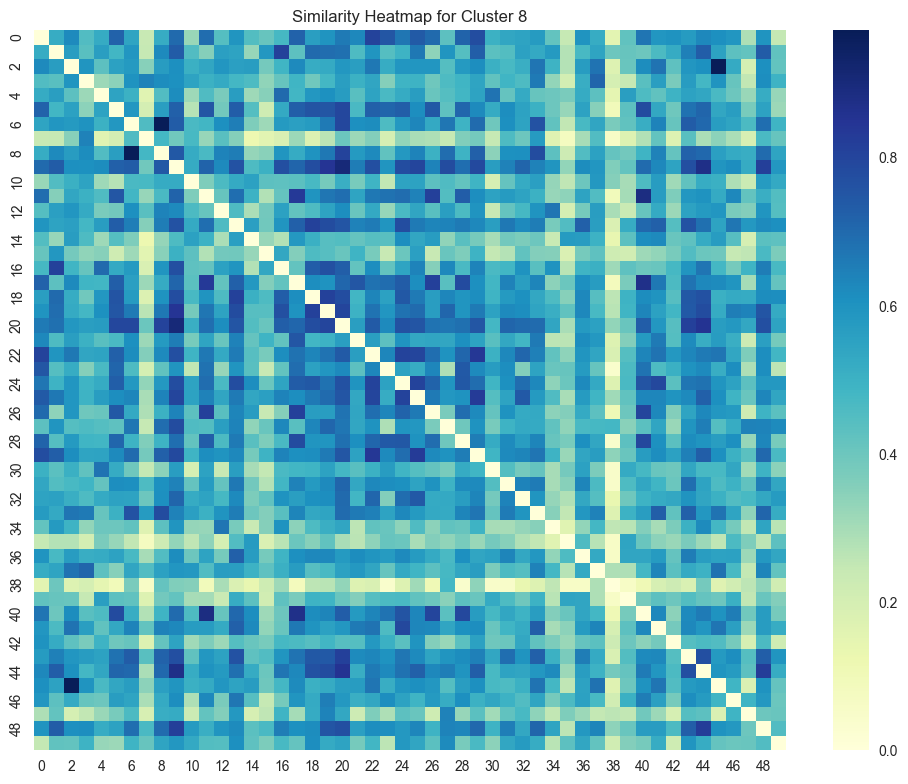


Analyzing Cluster 9 (26 documents)
Average similarity within cluster: 0.3978


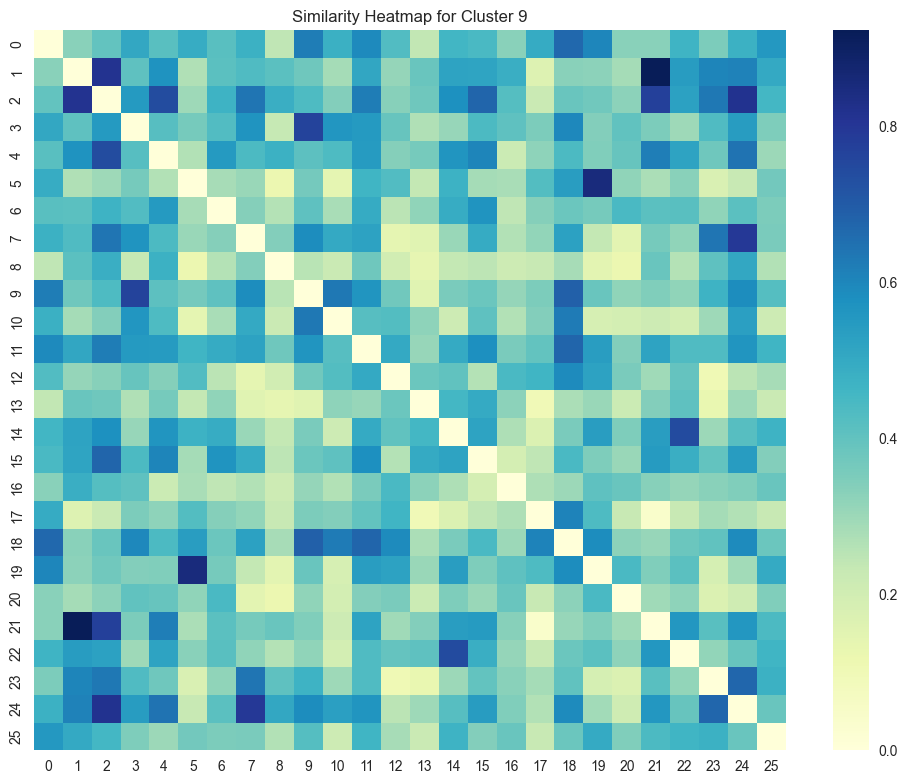


Analyzing Cluster 10 (25 documents)
Average similarity within cluster: 0.3598


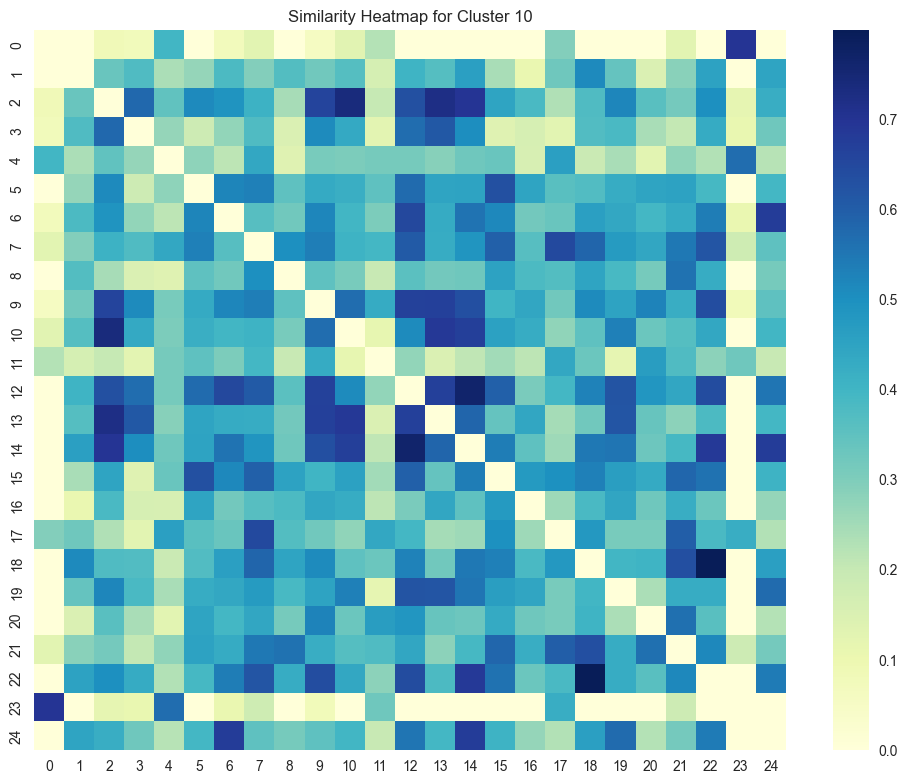


Analyzing Cluster 11 (36 documents)
Average similarity within cluster: 0.4688


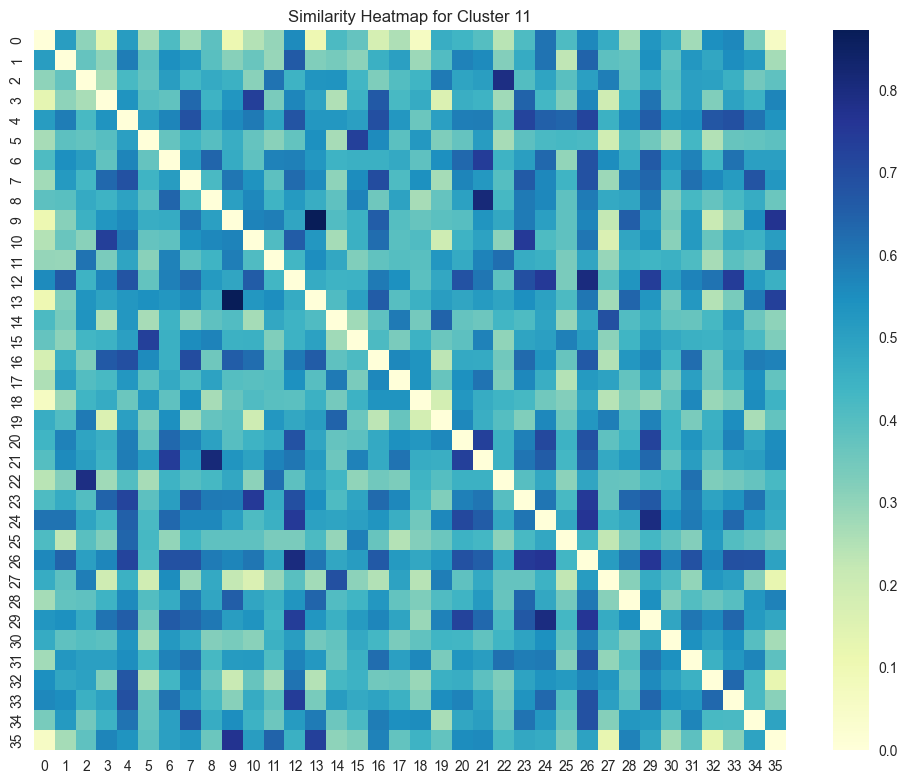


Analyzing Cluster 12 (39 documents)
Average similarity within cluster: 0.4665


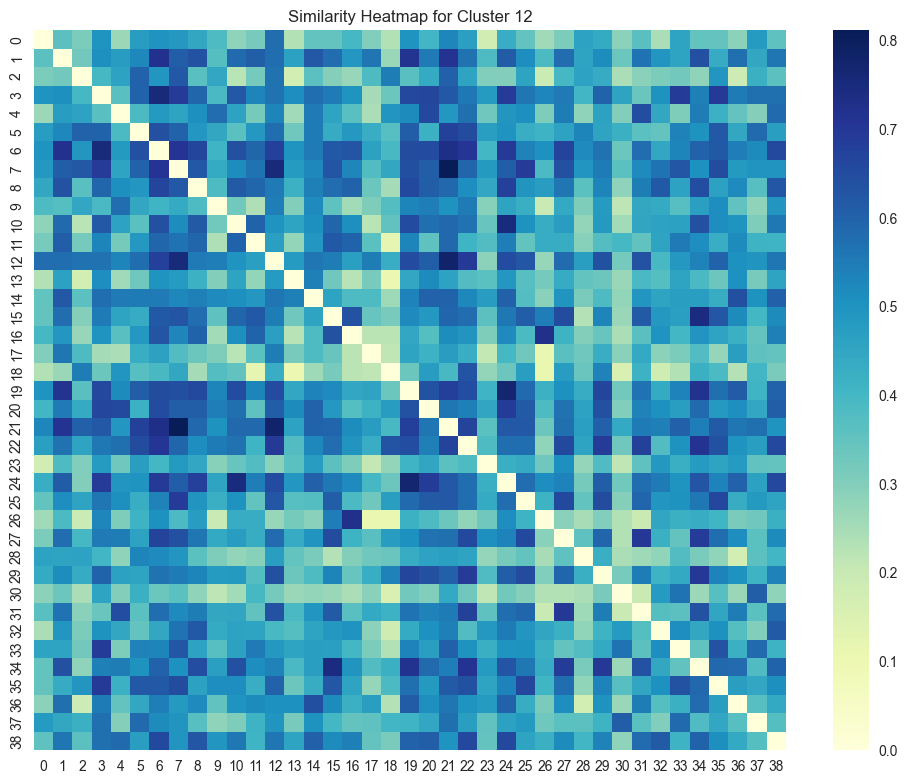


Analyzing Cluster 13 (27 documents)
Average similarity within cluster: 0.4383


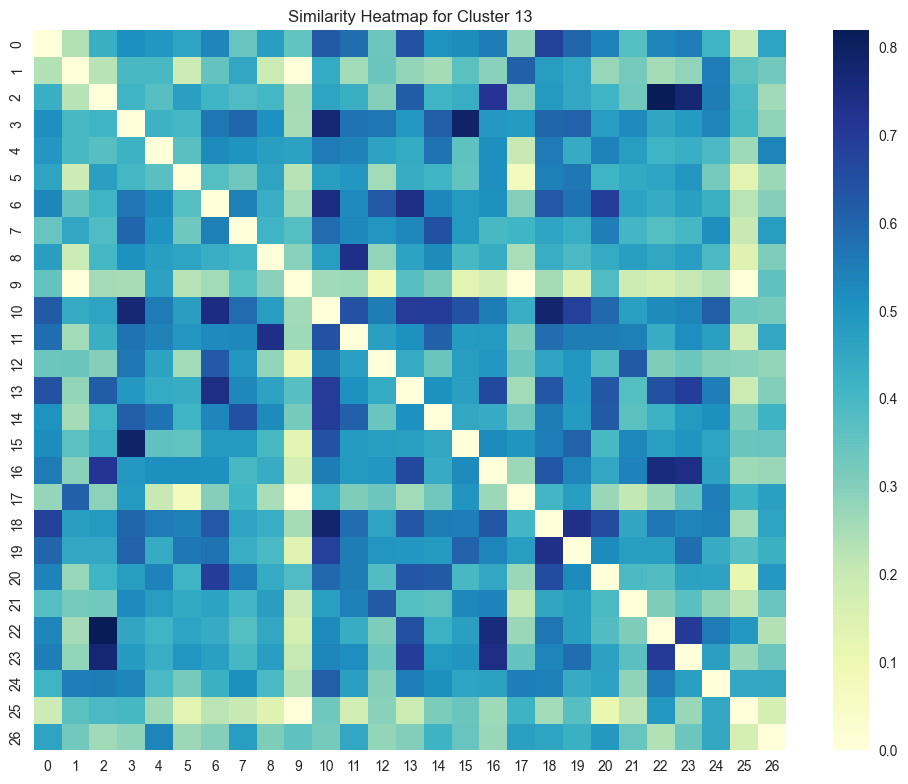


Analyzing Cluster 14 (19 documents)
Average similarity within cluster: 0.5392


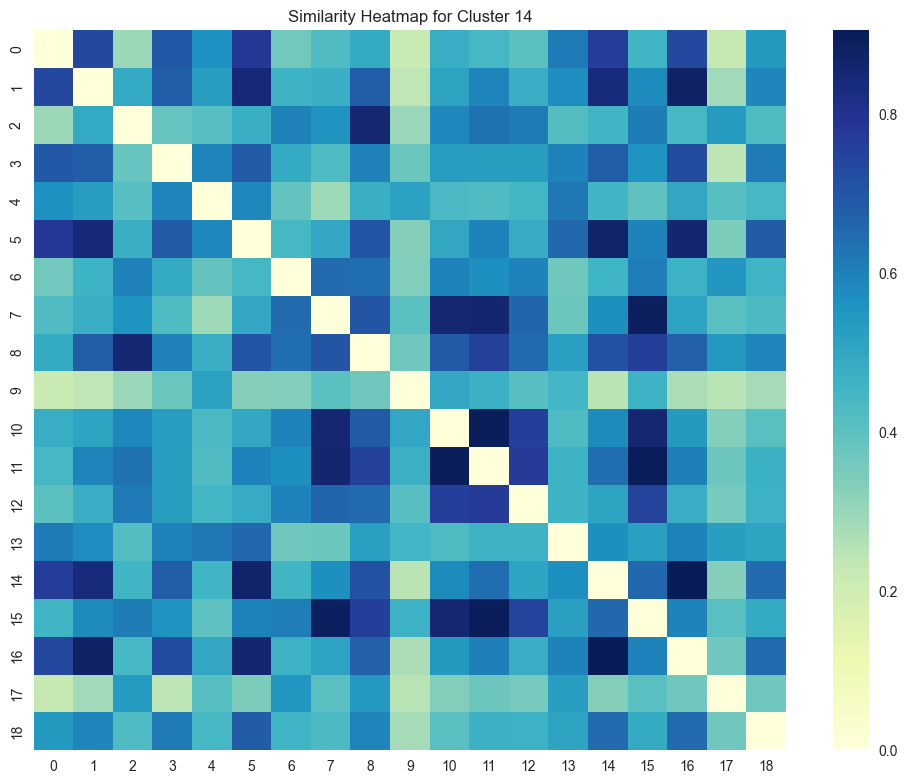


Analyzing Cluster 15 (32 documents)
Average similarity within cluster: 0.4367


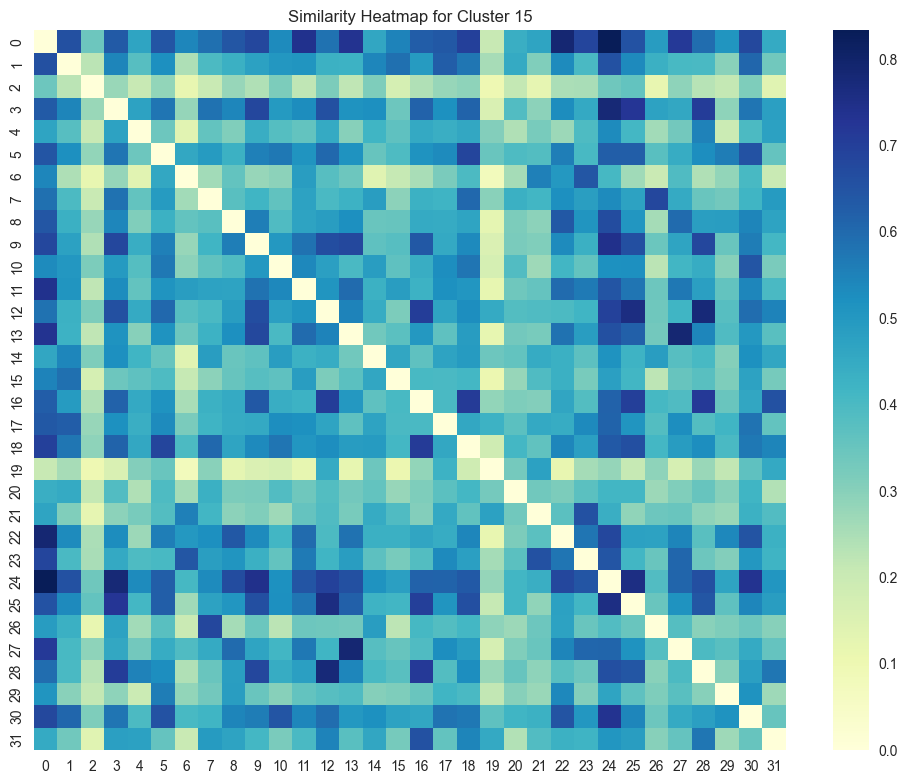


Analyzing Cluster 16 (20 documents)
Average similarity within cluster: 0.4606


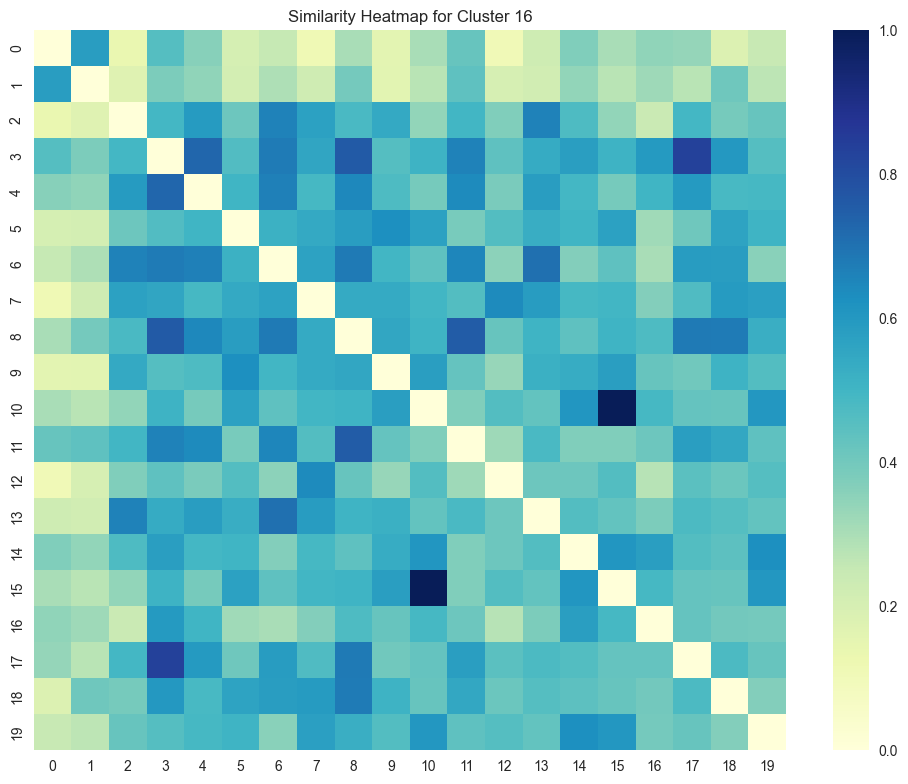


Analyzing Cluster 17 (42 documents)
Average similarity within cluster: 0.3300


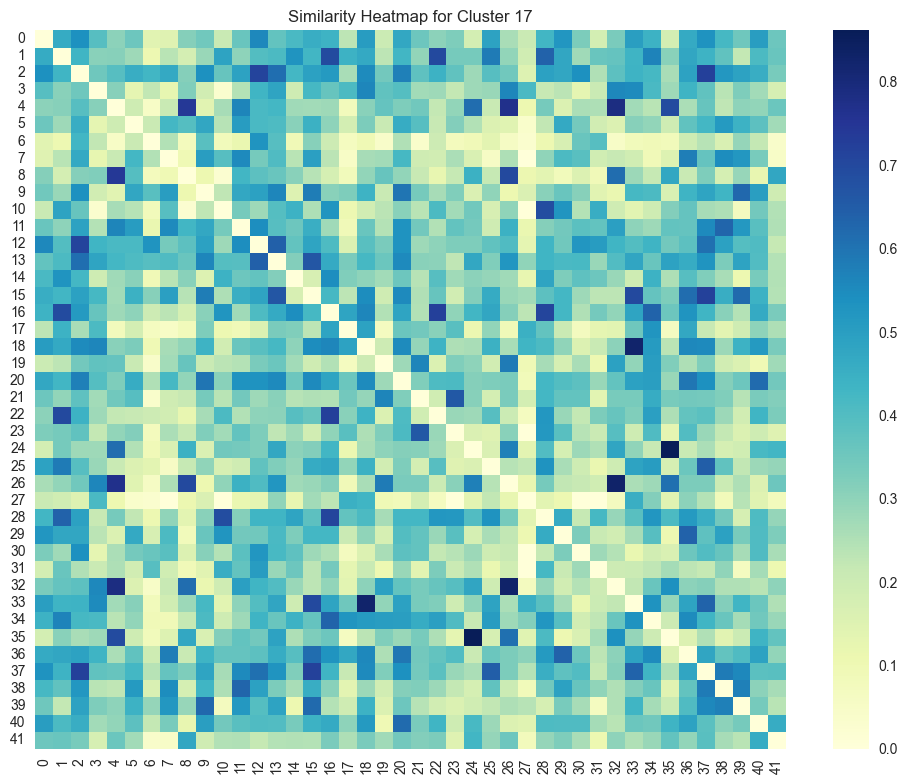


Analyzing Cluster 18 (15 documents)
Average similarity within cluster: 0.4732


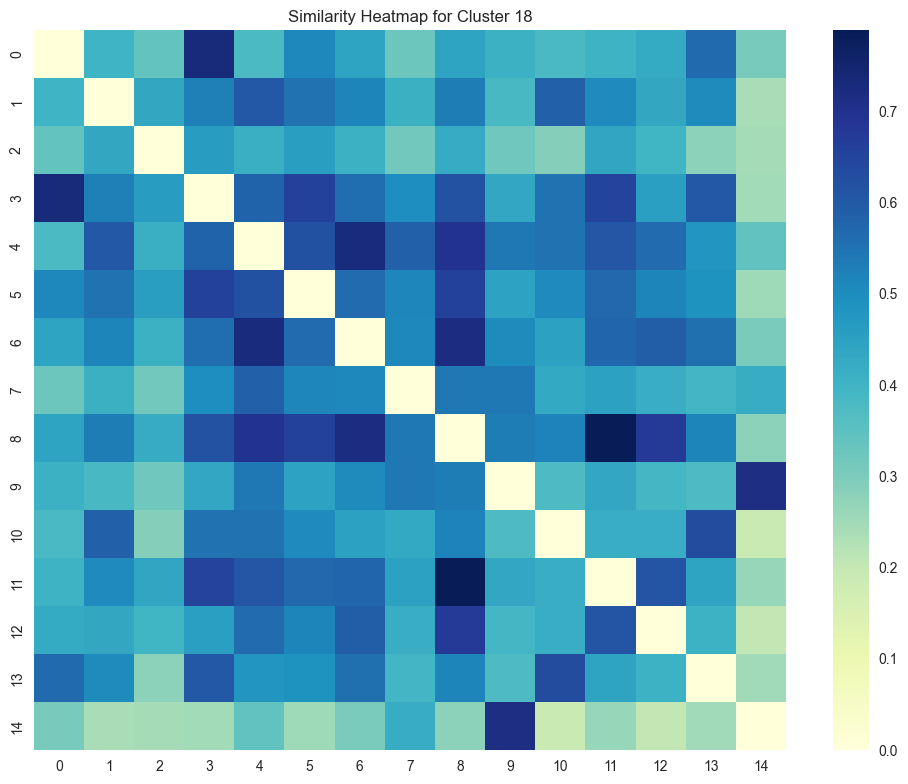


Analyzing Cluster 19 (20 documents)
Average similarity within cluster: 0.3758


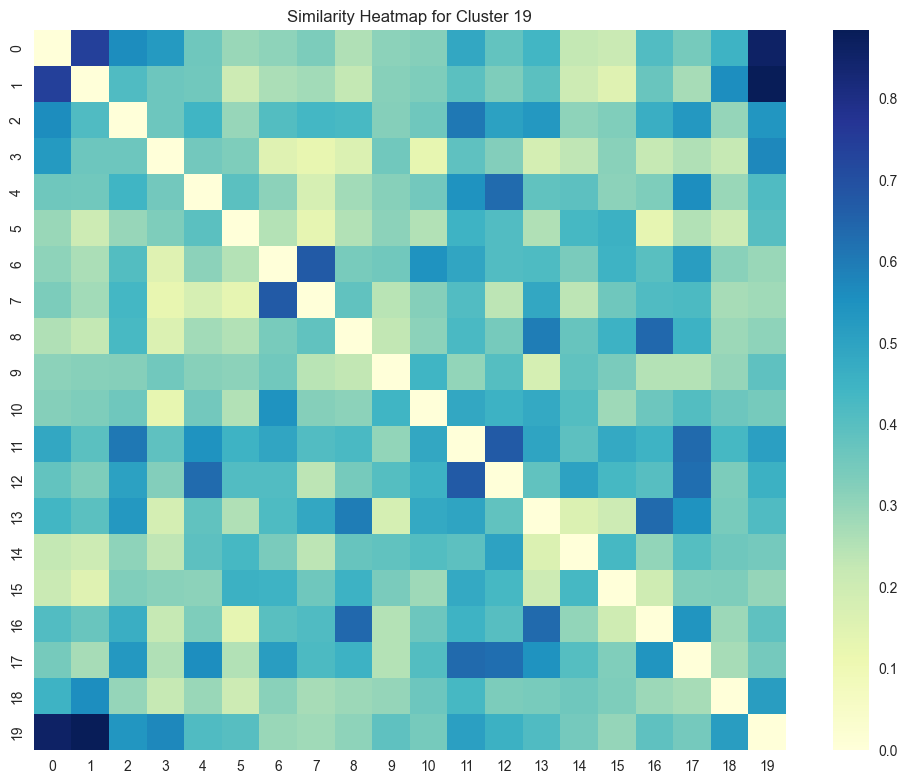

667


In [26]:
def visualize_basic_cluster_similarity(df, tfidf_matrix, summary_column):
    # Get unique clusters
    unique_clusters = sorted(df['Cluster'].unique())
    counter = 0
    for cluster_id in unique_clusters:
        # Get documents in this cluster
        cluster_docs = df[df['Cluster'] == cluster_id]
        cluster_indices = cluster_docs.index
        counter = counter + len(cluster_indices)
        # Skip if cluster has only one document
        if len(cluster_indices) <= 1:
            print(f"Cluster {cluster_id} has only {len(cluster_indices)} document(s). Skipping similarity analysis.")
            continue
            
        print(f"\nAnalyzing Cluster {cluster_id} ({len(cluster_indices)} documents)")
        
        # Extract TF-IDF vectors for documents in this cluster
        cluster_vectors = tfidf_matrix[cluster_indices]
        
        # Calculate cosine similarity between all documents in the cluster
        from sklearn.metrics.pairwise import cosine_similarity
        similarity_matrix = cosine_similarity(cluster_vectors)
        
        # Calculate average similarity
        import numpy as np
        np.fill_diagonal(similarity_matrix, 0)  # Exclude self-similarity
        avg_similarity = np.sum(similarity_matrix) / (len(cluster_indices) * (len(cluster_indices) - 1))
        print(f"Average similarity within cluster: {avg_similarity:.4f}")
        
        # Create a simple heatmap (only for clusters with reasonable size)
        if len(cluster_indices) <= 100:  # Only show heatmap for reasonably sized clusters
            import matplotlib.pyplot as plt
            import seaborn as sns
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(similarity_matrix, cmap='YlGnBu')
            plt.title(f'Similarity Heatmap for Cluster {cluster_id}')
            plt.tight_layout()
            plt.show()
    print(counter)

# Call the function with your data
visualize_basic_cluster_similarity(df, tfidf_matrix, df["Session_Summary"])